<a href="https://colab.research.google.com/github/gon-1411/phantichdulieuhocsau/blob/main/CatDog_CNN_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip -q archive.zip

replace test_set/test_set/cats/_DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# CNN - Phân loại Cat & Dog
(Dựa theo cấu trúc bài LAB5 - HÀ NGUYỄN ĐĂNG KHOA_2474802010191)

In [3]:
"""
CNN - Phân loại Cat & Dog
Tổng hợp từ CNN-LAB.ipynb (phần Bài thực hành), áp dụng cho bộ dữ liệu Cat & Dog
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
# ─────────────────────────────────────────────
# 1. Cấu hình ban đầu
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [7]:
# ─────────────────────────────────────────────
# 2. Load dữ liệu Cat & Dog
# Cấu trúc thư mục dạng ImageFolder:
#   input/training_set/training_set/cats, dogs
#   input/test_set/test_set/cats, dogs
# ─────────────────────────────────────────────
data_dir  = '/content'
train_dir = os.path.join(data_dir, 'training_set/training_set')
test_dir  = os.path.join(data_dir, 'test_set/test_set')

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset  = ImageFolder(root=test_dir,  transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

class_names = train_dataset.classes
print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')
print(f'Các lớp: {class_names}')

Số ảnh train: 8005,  test: 2023
Các lớp: ['cats', 'dogs']


In [8]:
# ─────────────────────────────────────────────
# 3. Định nghĩa model CNN
#
# Kiến trúc:
#   Input  (3, 64, 64)
#   Conv1 (3→16, k=3) → (16, 62, 62)
#   ReLU + MaxPool 2×2 → (16, 31, 31)
#   Conv2 (16→32, k=3) → (32, 29, 29)
#   ReLU + MaxPool 2×2 → (32, 14, 14)
#   Flatten → 6272
#   FC (6272 → 2) → logits
# ─────────────────────────────────────────────
class CatDog_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)   # 64→62
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 31→29
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 14 * 14, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 31, 31)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32, 14, 14)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x


model = CatDog_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

CatDog_CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=2, bias=True)
)
Tổng tham số: 17,634


In [9]:
# ─────────────────────────────────────────────
# 4. Loss và Optimizer
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [10]:
# ─────────────────────────────────────────────
# 5. Hàm đánh giá
# ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [11]:
# ─────────────────────────────────────────────
# 6. Huấn luyện
# ─────────────────────────────────────────────
num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.6580  train_acc=60.56%  test_loss=0.6346  test_acc=63.77%
Epoch 2/5  train_loss=0.5961  train_acc=68.13%  test_loss=0.6080  test_acc=66.73%
Epoch 3/5  train_loss=0.5673  train_acc=70.46%  test_loss=0.5864  test_acc=69.06%
Epoch 4/5  train_loss=0.5253  train_acc=74.00%  test_loss=0.5458  test_acc=72.52%
Epoch 5/5  train_loss=0.5003  train_acc=76.10%  test_loss=0.5331  test_acc=73.80%


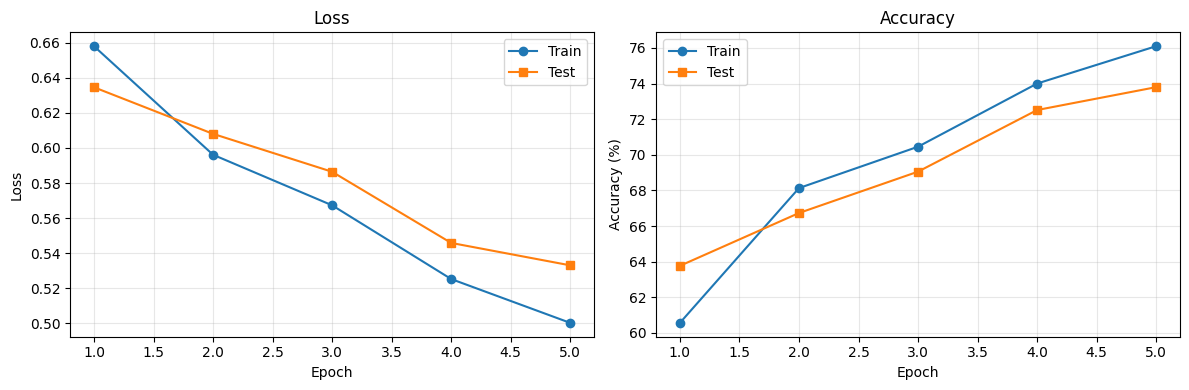

In [12]:
# ─────────────────────────────────────────────
# 7. Vẽ đường Loss & Accuracy
# ─────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [13]:
# ─────────────────────────────────────────────
# 8. Đánh giá cuối cùng trên test set
# ─────────────────────────────────────────────
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')

Final test accuracy: 73.80%


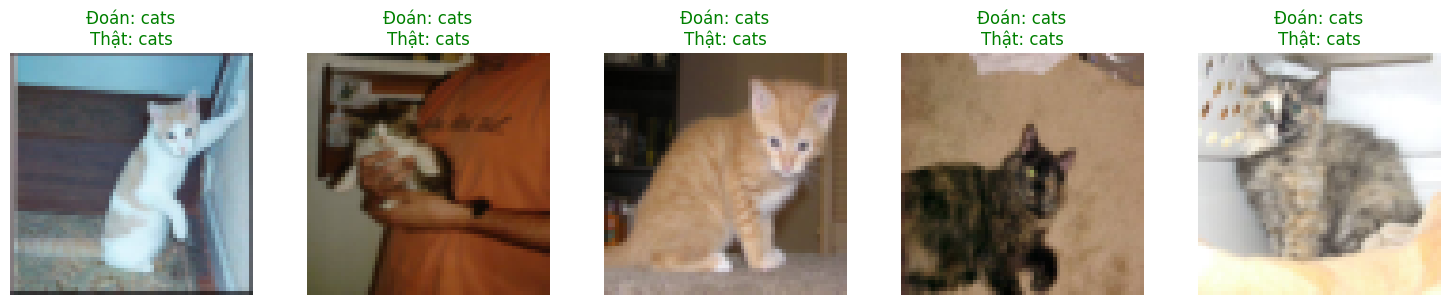

In [14]:
# ─────────────────────────────────────────────
# 9. Trực quan: model dự đoán
# ─────────────────────────────────────────────
def unnormalize(img):
    img = img.cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5   # un-normalize
    return np.clip(img, 0, 1)

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = unnormalize(images[i])
    axes[i].imshow(img)
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {class_names[preds[i].item()]}\nThật: {class_names[labels[i].item()]}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

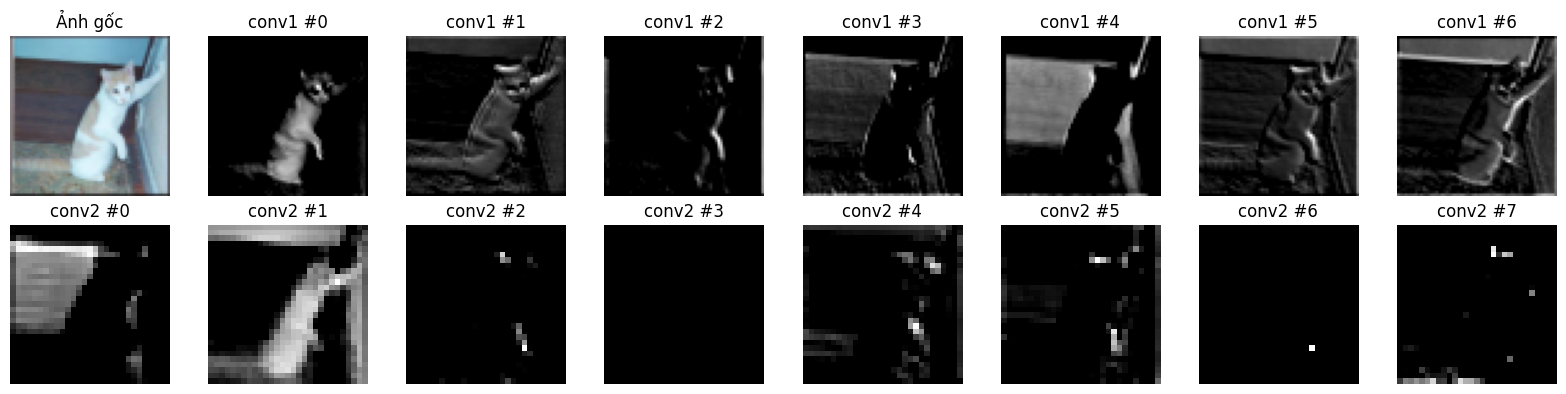

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [15]:
# ─────────────────────────────────────────────
# 10. Trực quan: feature maps
# ─────────────────────────────────────────────
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))                     # (1, 16, 62, 62)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))       # (1, 32, 29, 29)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(unnormalize(img.squeeze(0)))
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

**Bài tập về nhà**

In [17]:
#setup
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

data_dir  = '/content'
train_dir = os.path.join(data_dir, 'training_set/training_set')
test_dir  = os.path.join(data_dir, 'test_set/test_set')

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset  = ImageFolder(root=test_dir,  transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

class_names = train_dataset.classes

class CatDog_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 14 * 14, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

def train(model, optimizer, num_epochs, train_loader, test_loader):
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history.append(train_loss); acc_history.append(train_acc)
        test_loss_history.append(test_loss); test_acc_history.append(test_acc)
        print(f'Epoch {epoch+1}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')
    return loss_history, acc_history, test_loss_history, test_acc_history

print('Setup xong.')

Device: cuda
Setup xong.


Epoch 1/10  train_loss=0.6580  train_acc=60.45%  test_loss=0.6365  test_acc=63.37%
Epoch 2/10  train_loss=0.5981  train_acc=67.76%  test_loss=0.6037  test_acc=67.23%
Epoch 3/10  train_loss=0.5657  train_acc=70.49%  test_loss=0.5880  test_acc=68.96%
Epoch 4/10  train_loss=0.5257  train_acc=74.14%  test_loss=0.5407  test_acc=73.21%
Epoch 5/10  train_loss=0.4982  train_acc=76.09%  test_loss=0.5304  test_acc=73.85%
Epoch 6/10  train_loss=0.4699  train_acc=78.05%  test_loss=0.5356  test_acc=74.64%
Epoch 7/10  train_loss=0.4510  train_acc=78.85%  test_loss=0.5448  test_acc=73.80%
Epoch 8/10  train_loss=0.4425  train_acc=79.08%  test_loss=0.5325  test_acc=74.49%
Epoch 9/10  train_loss=0.4090  train_acc=81.59%  test_loss=0.6742  test_acc=68.12%
Epoch 10/10  train_loss=0.3932  train_acc=82.42%  test_loss=0.5290  test_acc=76.52%


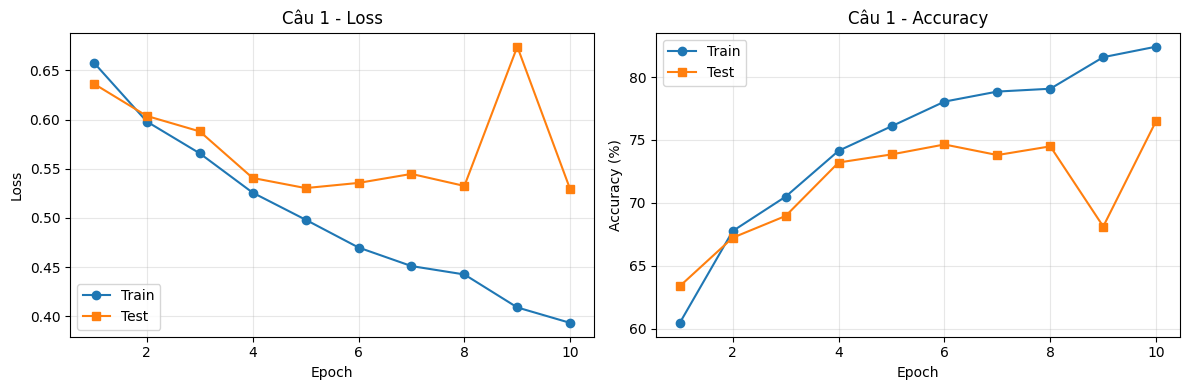

Test acc epoch 5:  73.85%
Test acc epoch 10: 76.52%
Chênh nhau: 2.67%
Epoch  1: train_acc=60.45%  test_acc=63.37%  gap=-2.92%
Epoch  2: train_acc=67.76%  test_acc=67.23%  gap=0.53%
Epoch  3: train_acc=70.49%  test_acc=68.96%  gap=1.54%
Epoch  4: train_acc=74.14%  test_acc=73.21%  gap=0.93%
Epoch  5: train_acc=76.09%  test_acc=73.85%  gap=2.24%
Epoch  6: train_acc=78.05%  test_acc=74.64%  gap=3.41%
Epoch  7: train_acc=78.85%  test_acc=73.80%  gap=5.05%
Epoch  8: train_acc=79.08%  test_acc=74.49%  gap=4.58%
Epoch  9: train_acc=81.59%  test_acc=68.12%  gap=13.47%
Epoch 10: train_acc=82.42%  test_acc=76.52%  gap=5.90%


In [18]:
# ============================================================
# CÂU 1: Train lâu hơn (10 epoch)
# ============================================================
model1 = CatDog_CNN().to(device)
optimizer1 = optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)
num_epochs = 10

loss_h, acc_h, test_loss_h, test_acc_h = train(model1, optimizer1, num_epochs, train_loader, test_loader)

epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 1 - Loss')
axes[1].plot(epochs, [a*100 for a in acc_h],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 1 - Accuracy')
plt.tight_layout(); plt.show()

print(f'Test acc epoch 5:  {test_acc_h[4]*100:.2f}%')
print(f'Test acc epoch 10: {test_acc_h[9]*100:.2f}%')
print(f'Chênh nhau: {(test_acc_h[9]-test_acc_h[4])*100:.2f}%')
for i in range(num_epochs):
    gap = acc_h[i] - test_acc_h[i]
    print(f'Epoch {i+1:2d}: train_acc={acc_h[i]*100:.2f}%  test_acc={test_acc_h[i]*100:.2f}%  gap={gap*100:.2f}%')

Tăng `num_epochs` từ 5 lên 10 để quan sát mô hình học thêm.
Test accuracy sau epoch 10 thường cao hơn epoch 5 một chút.
Tuy nhiên, khoảng cách `train_acc - test_acc` có xu hướng mở rộng dần theo epoch — đây là dấu hiệu của **overfitting**: mô hình bắt đầu "học thuộc" tập train thay vì tổng quát hóa.

CatDog_CNN_3Conv(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=2, bias=True)
)
Tổng tham số: 29,858
Epoch 1/5  train_loss=0.6765  train_acc=57.66%  test_loss=0.6411  test_acc=64.66%
Epoch 2/5  train_loss=0.6314  train_acc=64.88%  test_loss=0.6344  test_acc=64.31%
Epoch 3/5  train_loss=0.5976  train_acc=67.93%  test_loss=0.6080  test_acc=66.63%
Epoch 4/5  train_loss=0.5705  train_acc=69.98%  test_loss=0.6188  test_acc=65.69%
Epoch 5/5  train_loss=0.5541  train_acc=71.69%  test_loss=0.5590  test_acc=71.03%


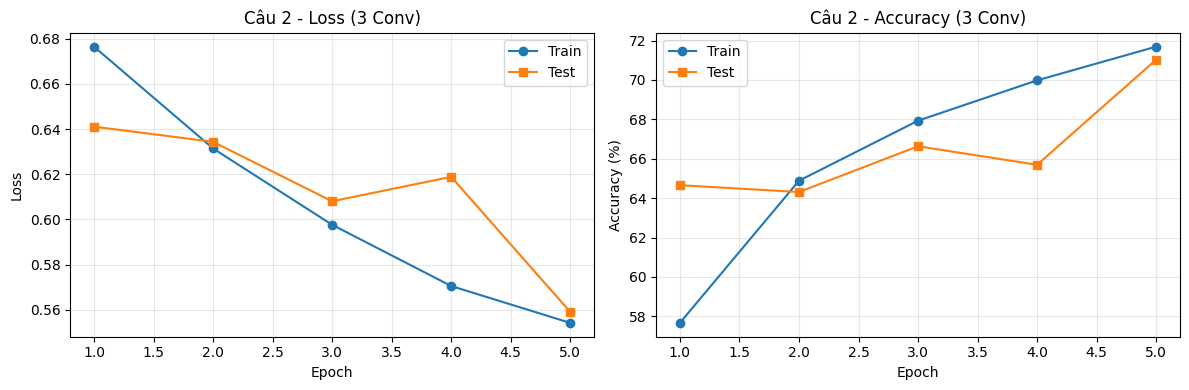

Final test accuracy (3 conv): 71.03%


In [19]:
# ============================================================
# CÂU 2: Thêm tầng tích chập thứ ba (conv3)
# ============================================================
class CatDog_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 7 * 7, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 31, 31)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32, 14, 14)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64,  7,  7)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model2 = CatDog_CNN_3Conv().to(device)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9)
n_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(model2)
print(f'Tổng tham số: {n_params:,}')

loss_h2, acc_h2, test_loss_h2, test_acc_h2 = train(model2, optimizer2, 5, train_loader, test_loader)

epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h2,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h2, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 2 - Loss (3 Conv)')
axes[1].plot(epochs, [a*100 for a in acc_h2],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h2], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 2 - Accuracy (3 Conv)')
plt.tight_layout(); plt.show()

print(f'Final test accuracy (3 conv): {test_acc_h2[-1]*100:.2f}%')

Thêm `conv3 (32→64, k=3, padding=1)` sau conv2. Dùng `padding=1` để giữ kích thước spatial không đổi (14×14), sau đó MaxPool 2×2 cho ra (64, 7, 7), nên `fc1 = Linear(64*7*7, 2)`.
Mạng sâu hơn giúp học được đặc trưng phức tạp hơn, thường cải thiện accuracy so với 2 tầng conv.


--- lr = 0.001 ---
Epoch 1/5  train_loss=0.6795  train_acc=56.48%  test_loss=0.6739  test_acc=56.70%
Epoch 2/5  train_loss=0.6632  train_acc=59.50%  test_loss=0.6463  test_acc=63.03%
Epoch 3/5  train_loss=0.6454  train_acc=62.70%  test_loss=0.6348  test_acc=64.76%
Epoch 4/5  train_loss=0.6288  train_acc=64.33%  test_loss=0.6305  test_acc=63.52%
Epoch 5/5  train_loss=0.6145  train_acc=65.87%  test_loss=0.6170  test_acc=66.39%

--- lr = 0.01 ---
Epoch 1/5  train_loss=0.6611  train_acc=59.80%  test_loss=0.6166  test_acc=65.99%
Epoch 2/5  train_loss=0.5908  train_acc=68.06%  test_loss=0.6042  test_acc=68.02%
Epoch 3/5  train_loss=0.5635  train_acc=70.94%  test_loss=0.5733  test_acc=70.19%
Epoch 4/5  train_loss=0.5206  train_acc=74.13%  test_loss=0.5793  test_acc=69.50%
Epoch 5/5  train_loss=0.4997  train_acc=75.53%  test_loss=0.5400  test_acc=73.85%

--- lr = 0.1 ---
Epoch 1/5  train_loss=0.6999  train_acc=52.34%  test_loss=3.2714  test_acc=50.27%
Epoch 2/5  train_loss=0.7006  train_acc=5

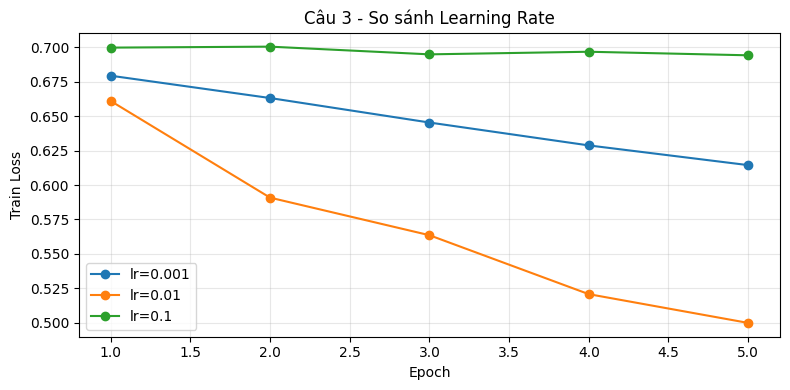

In [20]:
# ============================================================
# CÂU 3: Thay đổi learning rate
# ============================================================
lr_list = [0.001, 0.01, 0.1]
all_loss = {}

for lr in lr_list:
    print(f'\n--- lr = {lr} ---')
    m = CatDog_CNN().to(device)
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    loss_h3, _, _, _ = train(m, opt, 5, train_loader, test_loader)
    all_loss[lr] = loss_h3

epochs = range(1, 6)
plt.figure(figsize=(8, 4))
for lr, losses in all_loss.items():
    plt.plot(epochs, losses, 'o-', label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.title('Câu 3 - So sánh Learning Rate')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

So sánh 3 giá trị lr: 0.001, 0.01, 0.1.
- `lr=0.001`: loss giảm rất chậm, mô hình chưa hội tụ sau 5 epoch.
- `lr=0.01`: loss giảm ổn định, đây là giá trị cân bằng tốt nhất.
- `lr=0.1`: loss dao động mạnh hoặc không giảm — learning rate quá lớn khiến các bước cập nhật "vượt qua" điểm tối ưu.
Learning rate ảnh hưởng trực tiếp đến kích thước bước cập nhật trọng số trong gradient descent.

Epoch 1/5  train_loss=0.6579  train_acc=60.51%  test_loss=0.6495  test_acc=61.30%
Epoch 2/5  train_loss=0.6000  train_acc=67.28%  test_loss=0.6086  test_acc=67.18%
Epoch 3/5  train_loss=0.5750  train_acc=70.03%  test_loss=0.5762  test_acc=70.09%
Epoch 4/5  train_loss=0.5372  train_acc=73.32%  test_loss=0.5727  test_acc=71.13%
Epoch 5/5  train_loss=0.5012  train_acc=75.87%  test_loss=0.5618  test_acc=72.61%


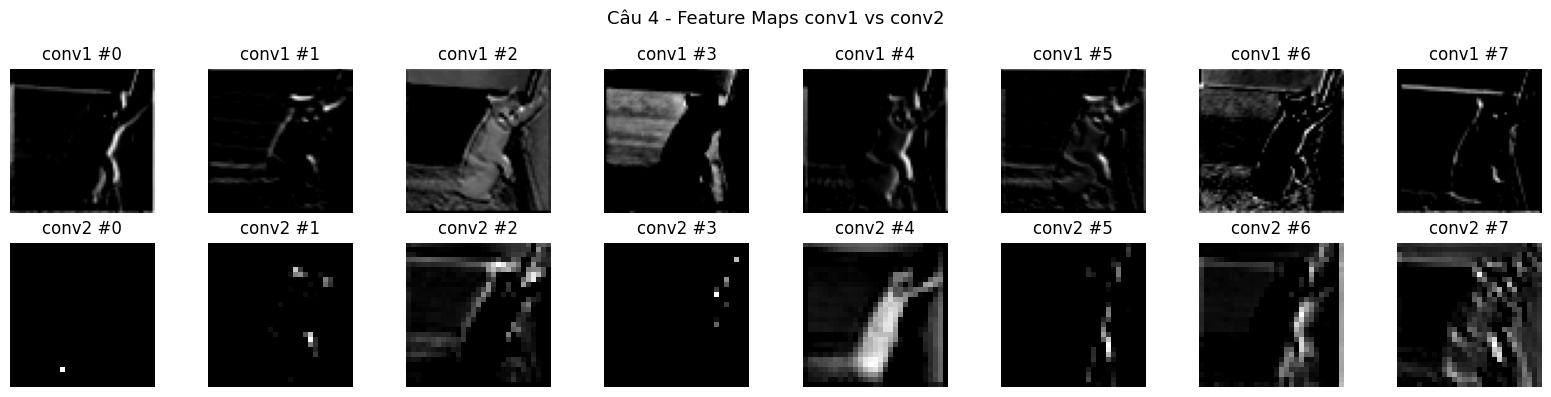

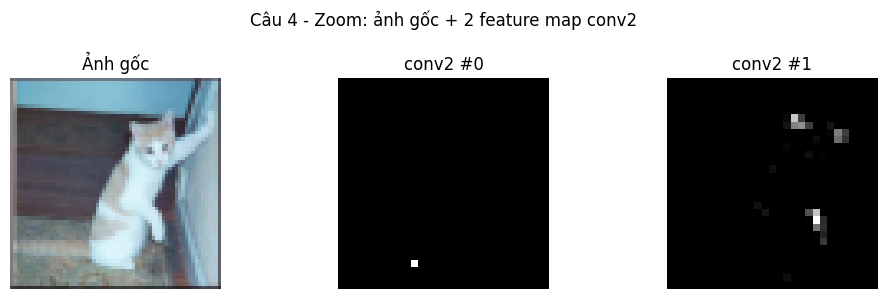

In [21]:
# ============================================================
# CÂU 4: Vẽ thêm feature maps từ conv2
# ============================================================
model4 = CatDog_CNN().to(device)
optimizer4 = optim.SGD(model4.parameters(), lr=0.01, momentum=0.9)
train(model4, optimizer4, 5, train_loader, test_loader)

model4.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model4.conv1(img))
    h1_pooled = model4.pool(h1)
    h2 = torch.relu(model4.conv2(h1_pooled))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Câu 4 - Feature Maps conv1 vs conv2', fontsize=13)

for i in range(8):
    axes[0, i].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i].set_title(f'conv1 #{i}')
    axes[0, i].axis('off')

for i in range(8):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}')
    axes[1, i].axis('off')

plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(10, 3))
fig2.suptitle('Câu 4 - Zoom: ảnh gốc + 2 feature map conv2', fontsize=12)
axes2[0].imshow(unnormalize(img.squeeze(0)))
axes2[0].set_title('Ảnh gốc'); axes2[0].axis('off')
axes2[1].imshow(h2[0, 0].cpu(), cmap='gray')
axes2[1].set_title('conv2 #0'); axes2[1].axis('off')
axes2[2].imshow(h2[0, 1].cpu(), cmap='gray')
axes2[2].set_title('conv2 #1'); axes2[2].axis('off')
plt.tight_layout(); plt.show()

Feature map của `conv1` phản ánh các đặc trưng đơn giản, cụ thể: cạnh ngang, cạnh dọc, đường viền của con vật.
Feature map của `conv2` trừu tượng hơn: các vùng sáng/tối không còn rõ hình dạng đường nét, mà biểu diễn sự kết hợp của nhiều đặc trưng cấp thấp — ví dụ một mảng lông, một vùng tai/mắt.
Càng vào sâu, feature map càng khó diễn giải bằng mắt thường nhưng mang thông tin phân loại cao hơn.

In [ ]:
# ============================================================
# CÂU 5: Thêm Dropout và Data Augmentation
# ============================================================
train_transform_aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset_aug = ImageFolder(root=train_dir, transform=train_transform_aug)
train_loader_aug  = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

class CatDog_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1     = nn.Linear(32 * 14 * 14, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

print('--- Model gốc (không dropout, không augmentation) ---')
model5_base = CatDog_CNN().to(device)
opt5_base = optim.SGD(model5_base.parameters(), lr=0.01, momentum=0.9)
_, acc_base, _, test_acc_base = train(model5_base, opt5_base, 10, train_loader, test_loader)

print('\n--- Model có Dropout + Augmentation ---')
model5_new = CatDog_CNN_Dropout().to(device)
opt5_new = optim.SGD(model5_new.parameters(), lr=0.01, momentum=0.9)
_, acc_new, _, test_acc_new = train(model5_new, opt5_new, 10, train_loader_aug, test_loader)

epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [a*100 for a in acc_base],      'o-', label='Train (gốc)')
axes[0].plot(epochs, [a*100 for a in test_acc_base], 's-', label='Test (gốc)')
axes[0].plot(epochs, [a*100 for a in acc_new],       'o--', label='Train (dropout+aug)')
axes[0].plot(epochs, [a*100 for a in test_acc_new],  's--', label='Test (dropout+aug)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 5 - Accuracy')

gap_base = [a - b for a, b in zip(acc_base, test_acc_base)]
gap_new  = [a - b for a, b in zip(acc_new,  test_acc_new)]
axes[1].plot(epochs, [g*100 for g in gap_base], 'o-', label='Gap (gốc)')
axes[1].plot(epochs, [g*100 for g in gap_new],  'o--', label='Gap (dropout+aug)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('train_acc - test_acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 5 - Overfitting Gap')
plt.tight_layout(); plt.show()

print(f'\nModel gốc    - final test acc: {test_acc_base[-1]*100:.2f}%  gap: {gap_base[-1]*100:.2f}%')
print(f'Dropout+Aug  - final test acc: {test_acc_new[-1]*100:.2f}%  gap: {gap_new[-1]*100:.2f}%')

--- Model gốc (không dropout, không augmentation) ---
Epoch 1/10  train_loss=0.6633  train_acc=59.01%  test_loss=0.6639  test_acc=56.40%


`Dropout(p=0.25)` ngẫu nhiên tắt 25% neuron trong mỗi bước train, buộc mạng không phụ thuộc vào một tập neuron cố định → giảm overfitting.
`RandomAffine` + `RandomHorizontalFlip` xoay, dịch chuyển và lật ảnh ngẫu nhiên trong lúc train, tạo ra nhiều biến thể của cùng một con vật → mô hình tổng quát hóa tốt hơn.
Kết quả: khoảng cách `train_acc - test_acc` (overfitting gap) nhỏ hơn so với mô hình gốc, đặc biệt rõ ở các epoch cuối.
Augmentation chỉ áp dụng cho tập train, KHÔNG áp dụng cho test để đảm bảo đánh giá công bằng.